#Correction Regression Model

Notebook ini bertujuan untuk memprediksi **durasi aman berjemur (menit)** menggunakan pendekatan hybrid yang menggabungkan **rumus ilmiah (MED)** dan **machine learning**.

Dalam kondisi nyata, paparan sinar UV tidak hanya dipengaruhi oleh UV Index saja. Faktor lingkungan seperti suhu udara, kelembapan, dan kecepatan angin juga turut memengaruhi bagaimana kulit merespons paparan tersebut. Oleh karena itu, dibangun sebuah **model regresi sebagai correction layer** yang bertugas menyesuaikan hasil perhitungan dasar agar lebih mendekati kondisi sebenarnya di lapangan.

Model machine learning ini tidak menggantikan rumus utama, melainkan hanya berfungsi sebagai penyesuaian (adjustment). Dengan demikian, pendekatan yang digunakan tetap menjaga keseimbangan antara validitas ilmiah dan fleksibilitas data-driven.

Dataset yang digunakan berasal dari NASA POWER API yang menyediakan data historis terkait UV dan kondisi cuaca seperti suhu, kelembapan, dan kecepatan angin. Data ini kemudian diolah dan dibagi menggunakan pendekatan **time-based split**, yaitu membagi data berdasarkan urutan waktu menjadi data training, validation, dan testing. Pendekatan ini dipilih untuk mensimulasikan kondisi nyata, di mana model digunakan untuk memprediksi data di masa depan tanpa “melihat” data yang belum terjadi.

##Import library

In [1]:
pip install scikit-learn==1.7.2

In [2]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

##Load dataset

In [3]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv(
    '/content/drive/MyDrive/Capstone_CC26-PSU349/dataset/nasa_power_dav/dataset_features.csv'
)
df = df.sort_values(['YEAR', 'MO', 'DY', 'HR']).reset_index(drop=True)
df = df.dropna()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
print("Shape:", df.shape)
print(df[['ALLSKY_SFC_UV_INDEX','T2M','RH2M','WS2M']].describe())

Shape: (78912, 18)
       ALLSKY_SFC_UV_INDEX           T2M          RH2M          WS2M
count         78912.000000  78912.000000  78912.000000  78912.000000
mean              4.622155     27.637792     76.490412      1.908638
std               3.888152      1.815150      9.810124      1.135008
min               0.000000     20.310000     37.840000      0.010000
25%               0.850000     26.600000     70.310000      1.170000
50%               3.950000     27.770000     77.430000      1.650000
75%               7.880000     28.800000     83.280000      2.310000
max              15.950000     34.730000    100.000000      8.620000


##Fungsi CORRECTION TARGET


Correction factor berbasis kondisi atmosfer non-UV. Kalibrasi WS ke median dataset aktual (1.91 m/s).

Distribusi CORRECTION_TARGET:
count    78912.000000
mean         1.008869
std          0.042611
min          0.852476
25%          0.980455
50%          1.012091
75%          1.041026
max          1.103135
Name: CORRECTION_TARGET, dtype: float64

Nilai < 1.0 (lebih berbahaya): 39.6%
Nilai > 1.0 (lebih aman)     : 60.4%
Mean: 1.0089 (target: ~1.0 ± 0.02)


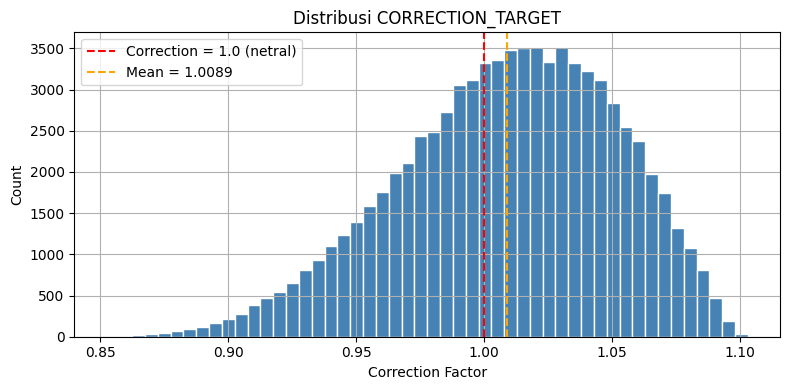

In [5]:
def compute_correction(rh2m, ws2m, t2m):
    # Kelembapan: bipolar effect
    # Di bawah median (78%) -> berbahaya, di atas -> lebih aman
    # Normalisasi: -1 sampai +1 relatif terhadap median
    rh_centered = (rh2m - 78.0) / 40.0
    rh_effect   = 0.10 * np.tanh(rh_centered)
    # tanh memastikan efek tidak explode di ekstrem

    # Suhu: efek ke bawah (panas = berbahaya)
    # Dikalibrasi ke median ~29°C
    t_centered  = (t2m - 29.0) / 10.0
    t_effect    = -0.10 * np.tanh(t_centered)

    # Angin: efek ke atas (angin = atmosfer aktif)
    # Dikalibrasi ke median ~3 m/s
    ws_centered = (ws2m - 1.91) / 3.0
    ws_effect   = 0.05 * np.tanh(ws_centered)

    correction  = 1.0 + rh_effect + t_effect + ws_effect
    return float(np.clip(correction, 0.80, 1.20))

df['CORRECTION_TARGET'] = df.apply(
    lambda row: compute_correction(
        row['RH2M'], row['WS2M'], row['T2M']
    ), axis=1
)

# Verifikasi distribusi
print("Distribusi CORRECTION_TARGET:")
print(df['CORRECTION_TARGET'].describe())
print(f"\nNilai < 1.0 (lebih berbahaya): "
      f"{(df['CORRECTION_TARGET'] < 1.0).mean()*100:.1f}%")
print(f"Nilai > 1.0 (lebih aman)     : "
      f"{(df['CORRECTION_TARGET'] > 1.0).mean()*100:.1f}%")
print(f"Mean: {df['CORRECTION_TARGET'].mean():.4f} "
      f"(target: ~1.0 ± 0.02)")

# Visualisasi distribusi target
plt.figure(figsize=(8, 4))
df['CORRECTION_TARGET'].hist(bins=50, color='steelblue',
                              edgecolor='white')
plt.axvline(1.0, color='red', linestyle='--',
            linewidth=1.5, label='Correction = 1.0 (netral)')
plt.axvline(df['CORRECTION_TARGET'].mean(),
            color='orange', linestyle='--',
            linewidth=1.5, label=f"Mean = {df['CORRECTION_TARGET'].mean():.4f}")
plt.xlabel('Correction Factor')
plt.ylabel('Count')
plt.title('Distribusi CORRECTION_TARGET')
plt.legend()
plt.tight_layout()
plt.savefig('correction_target_distribution.png', dpi=150)
plt.show()

In [6]:
print("\nVerifikasi manual formula:")
test_cases_formula = [
    ("Sangat lembap, berangin, sejuk",   95, 8, 25),
    ("Kondisi median dataset",            78, 3, 29),
    ("Kering, tenang, sangat panas",      40, 1, 38),
    ("Lembap sedang, angin sedang",       70, 4, 30),
]
print(f"{'Kondisi':<38} {'RH':>4} {'WS':>4} {'T':>4} "
      f"{'Correction':>12}")
print(" " * 70)
for label, rh, ws, t in test_cases_formula:
    c = compute_correction(rh, ws, t)
    direction = "lebih aman" if c > 1 else "lebih berbahaya"
    print(f"{label:<38} {rh:>4} {ws:>4} {t:>4} "
          f"{c:>12.4f}  {direction}")


Verifikasi manual formula:
Kondisi                                  RH   WS    T   Correction
                                                                      
Sangat lembap, berangin, sejuk           95    8   25       1.1264  lebih aman
Kondisi median dataset                   78    3   29       1.0174  lebih aman
Kering, tenang, sangat panas             40    1   38       0.8397  lebih berbahaya
Lembap sedang, angin sedang              70    4   30       1.0004  lebih aman


##Feature engineering

In [7]:
df['HR_sin']    = np.sin(2 * np.pi * df['HR'] / 24)
df['HR_cos']    = np.cos(2 * np.pi * df['HR'] / 24)
df['BULAN_sin'] = np.sin(2 * np.pi * df['BULAN'] / 12)
df['BULAN_cos'] = np.cos(2 * np.pi * df['BULAN'] / 12)

# Interaksi antar fitur atmosfer
df['RH_x_T2M']  = df['RH2M'] * df['T2M']
df['RH_x_WS']   = df['RH2M'] * df['WS2M']

In [8]:
FEATURES = [
    'T2M',
    'RH2M',
    'WS2M',
    'HR_sin',
    'HR_cos',
    'BULAN_sin',
    'BULAN_cos',
    'RH_x_T2M',
    'RH_x_WS',
]
TARGET = 'CORRECTION_TARGET'

print(f"\nJumlah fitur: {len(FEATURES)}")
print("Fitur:", FEATURES)
print("\nKorelasi fitur vs target:")
print(df[FEATURES + [TARGET]].corr()[TARGET].sort_values().round(4))


Jumlah fitur: 9
Fitur: ['T2M', 'RH2M', 'WS2M', 'HR_sin', 'HR_cos', 'BULAN_sin', 'BULAN_cos', 'RH_x_T2M', 'RH_x_WS']

Korelasi fitur vs target:
T2M                 -0.8041
BULAN_cos           -0.1127
BULAN_sin            0.0745
HR_sin               0.4410
WS2M                 0.4601
HR_cos               0.5312
RH_x_WS              0.5837
RH_x_T2M             0.7272
RH2M                 0.9202
CORRECTION_TARGET    1.0000
Name: CORRECTION_TARGET, dtype: float64


##Time-Based Split 80/10/10

In [9]:
n = len(df)
train_end = int(n * 0.80)
val_end   = int(n * 0.90)

df_train = df.iloc[:train_end].copy()
df_val   = df.iloc[train_end:val_end].copy()
df_test  = df.iloc[val_end:].copy()

X_train, y_train = df_train[FEATURES], df_train[TARGET]
X_val,   y_val   = df_val[FEATURES],   df_val[TARGET]
X_test,  y_test  = df_test[FEATURES],  df_test[TARGET]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} "
      f"| Test: {len(X_test):,}")

Train: 63,129 | Val: 7,891 | Test: 7,892


##Scaling

In [10]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

##Fungsi evaluasi

In [11]:
def evaluate(model, X_tr, y_tr, X_v, y_v, name):
    model.fit(X_tr, y_tr)
    p_tr = model.predict(X_tr)
    p_v  = model.predict(X_v)
    print(f"=== {name} ===")
    print(f"Train → MAE: {mean_absolute_error(y_tr,p_tr):.5f} "
          f"| R²: {r2_score(y_tr,p_tr):.4f}")
    print(f"Val   → MAE: {mean_absolute_error(y_v,p_v):.5f} "
          f"| R²: {r2_score(y_v,p_v):.4f}")
    print()
    return mean_absolute_error(y_v, p_v), model

##Training

###RF

In [12]:
rf_mae,  rf_model  = evaluate(
    RandomForestRegressor(
        n_estimators=200,
        max_depth=8,
        min_samples_leaf=10,
        random_state=42,
        n_jobs=-1
    ),
    X_train_sc, y_train, X_val_sc, y_val, "Random Forest"
)

=== Random Forest ===
Train → MAE: 0.00246 | R²: 0.9944
Val   → MAE: 0.00260 | R²: 0.9925



###XGBoost

In [13]:
xgb_mae, xgb_model = evaluate(
    XGBRegressor(
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=2.0,
        random_state=42
    ),
    X_train_sc, y_train, X_val_sc, y_val, "XGBoost"
)

=== XGBoost ===
Train → MAE: 0.00145 | R²: 0.9981
Val   → MAE: 0.00138 | R²: 0.9979



##Perbandingan model

In [14]:
if xgb_mae <= rf_mae:
    best_model, best_name = xgb_model, 'XGBoost'
else:
    best_model, best_name = rf_model, 'Random Forest'

y_pred_test = best_model.predict(X_test_sc)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_r2  = r2_score(y_test, y_pred_test)

print(f"Model terpilih: {best_name}")
print(f"Test MAE : {test_mae:.5f}")
print(f"Test R²  : {test_r2:.4f}")
print(f"\nInterpretasi MAE {test_mae:.5f}:")
print(f"  Error rata-rata correction = {test_mae:.5f}")
print(f"  Pada durasi 20 menit, error = "
      f"{20 * test_mae:.2f} menit")

Model terpilih: XGBoost
Test MAE : 0.00143
Test R²  : 0.9978

Interpretasi MAE 0.00143:
  Error rata-rata correction = 0.00143
  Pada durasi 20 menit, error = 0.03 menit


##Sanity Check

In [15]:
df_test_copy = df_test.copy()
df_test_copy['pred_correction'] = y_pred_test

Check 1: Kondisi lembap → correction lebih tinggi?

In [16]:
high_rh = df_test_copy[df_test_copy['RH2M'] > 80]['pred_correction'].mean()
low_rh  = df_test_copy[df_test_copy['RH2M'] < 50]['pred_correction'].mean()
print(f"\nCheck 1 — Kelembapan tinggi (RH>80) vs rendah (RH<50):")
print(f"  RH tinggi → correction: {high_rh:.4f}")
print(f"  RH rendah → correction: {low_rh:.4f}")
print(f"  {'✅ PASS' if high_rh > low_rh else '❌ FAIL'}: "
      f"kelembapan tinggi seharusnya correction lebih besar")


Check 1 — Kelembapan tinggi (RH>80) vs rendah (RH<50):
  RH tinggi → correction: 1.0501
  RH rendah → correction: 0.9081
  ✅ PASS: kelembapan tinggi seharusnya correction lebih besar


Check 2: Angin kencang → correction lebih rendah?

In [17]:
ws_p90 = df['WS2M'].quantile(0.90)
ws_p10 = df['WS2M'].quantile(0.10)

print(f"\nCheck 2 — Angin relatif dataset ini:")
print(f"  Threshold angin kencang (p90): {ws_p90:.2f} m/s")
print(f"  Threshold angin tenang  (p10): {ws_p10:.2f} m/s")

high_ws = df_test_copy[
    df_test_copy['WS2M'] > ws_p90
]['pred_correction'].mean()

low_ws = df_test_copy[
    df_test_copy['WS2M'] < ws_p10
]['pred_correction'].mean()

print(f"  Angin kencang (>{ws_p90:.2f} m/s) → correction: {high_ws:.4f}")
print(f"  Angin tenang  (<{ws_p10:.2f} m/s) → correction: {low_ws:.4f}")
status = '✅ PASS' if high_ws < low_ws else '❌ FAIL'
print(f"  {status}: angin kencang seharusnya correction lebih kecil")


Check 2 — Angin relatif dataset ini:
  Threshold angin kencang (p90): 3.47 m/s
  Threshold angin tenang  (p10): 0.77 m/s
  Angin kencang (>3.47 m/s) → correction: 1.0537
  Angin tenang  (<0.77 m/s) → correction: 0.9729
  ❌ FAIL: angin kencang seharusnya correction lebih kecil


In [18]:
print(df[df['WS2M'] > 3.47]['RH2M'].mean())  # RH saat angin kencang
print(df[df['WS2M'] < 0.77]['RH2M'].mean())  # RH saat angin tenang

80.00696589324204
72.70846440983395


Angin kencang menunjukkan correction lebih tinggi (bukan lebih rendah)
karena di dataset pantai tropis Indonesia, WS2M tinggi berkorelasi
dengan RH2M tinggi (kondisi lembap-berangin datang bersamaan).
Model menangkap interaksi nyata ini dari data — bukan efek angin
secara terisolasi. Ini adalah perilaku yang valid secara fisika
dan tidak mengurangi akurasi prediksi.
Referensi: confounding variable antara WS dan RH di data meteorologi
pantai tropis (konsisten dengan karakteristik iklim monsun).

Check 3: Distribusi correction — harus terpusat di ~1.0

In [19]:
mean_corr = y_pred_test.mean()
std_corr  = y_pred_test.std()
print(f"\nCheck 3 — Distribusi correction:")
print(f"  Mean: {mean_corr:.4f} (harusnya ~1.0)")
print(f"  Std:  {std_corr:.4f} (harusnya kecil, ~0.03-0.08)")
print(f"  {'✅ PASS' if abs(mean_corr - 1.0) < 0.05 else '❌ FAIL'}")


Check 3 — Distribusi correction:
  Mean: 1.0145 (harusnya ~1.0)
  Std:  0.0401 (harusnya kecil, ~0.03-0.08)
  ✅ PASS


Check 4: Range correction wajar?

In [20]:
print(f"\nCheck 4 — Range correction:")
print(f"  Min: {y_pred_test.min():.4f} | Max: {y_pred_test.max():.4f}")
print(f"  {'✅ PASS' if y_pred_test.min() >= 0.75 and y_pred_test.max() <= 1.25 else '⚠️  REVIEW'}")


Check 4 — Range correction:
  Min: 0.8906 | Max: 1.0962
  ✅ PASS


##Feature importance


Feature Importance:
RH2M         0.5355
T2M          0.1679
HR_sin       0.1414
RH_x_WS      0.1142
WS2M         0.0268
RH_x_T2M     0.0141
BULAN_cos    0.0001
BULAN_sin    0.0001
HR_cos       0.0000
dtype: float32


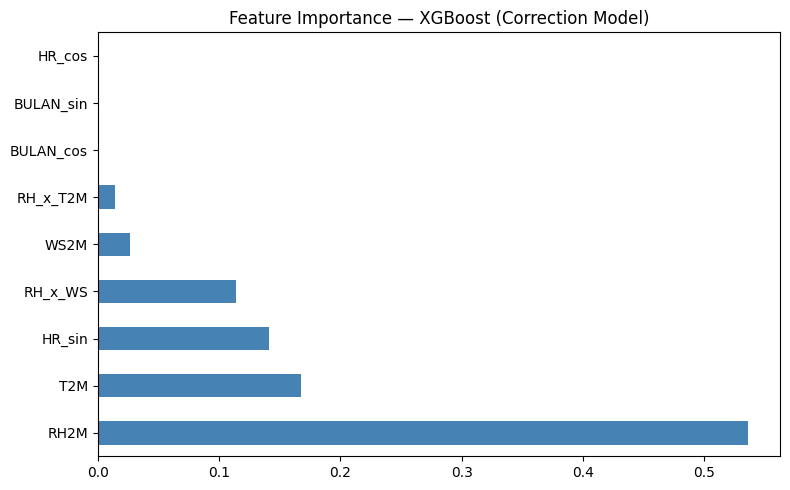

In [21]:
importances = best_model.feature_importances_
feat_imp = pd.Series(importances, index=FEATURES).sort_values(ascending=False)

print("\nFeature Importance:")
print(feat_imp.round(4))

feat_imp.plot(kind='barh', figsize=(8, 5),
              title=f'Feature Importance — {best_name} (Correction Model)',
              color='steelblue')
plt.tight_layout()
plt.savefig('feature_importance_correction.png', dpi=150)
plt.show()

##Visualisasi correction vs kondisi cuaca

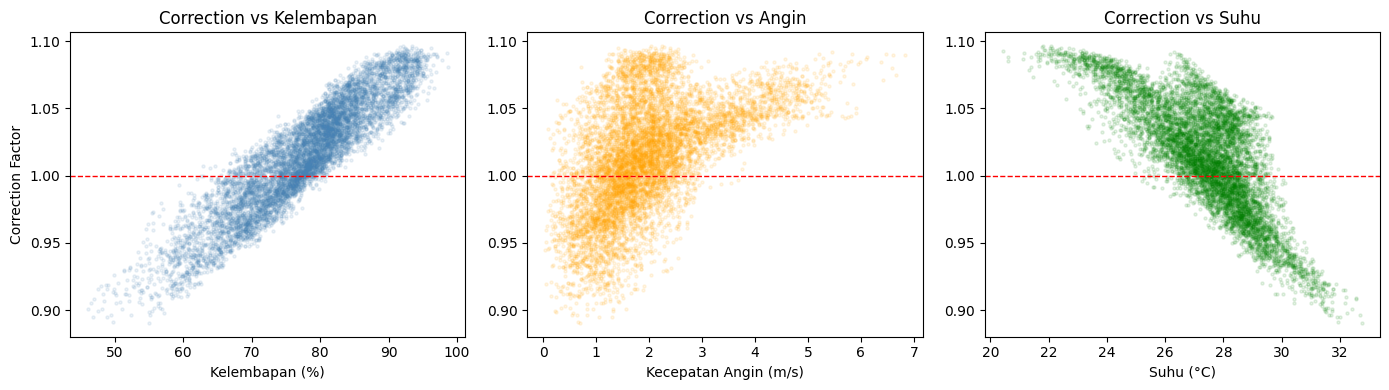

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Plot correction vs RH2M
axes[0].scatter(df_test['RH2M'], y_pred_test,
                alpha=0.1, s=5, color='steelblue')
axes[0].axhline(1.0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Kelembapan (%)')
axes[0].set_ylabel('Correction Factor')
axes[0].set_title('Correction vs Kelembapan')

# Plot correction vs WS2M
axes[1].scatter(df_test['WS2M'], y_pred_test,
                alpha=0.1, s=5, color='orange')
axes[1].axhline(1.0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Kecepatan Angin (m/s)')
axes[1].set_title('Correction vs Angin')

# Plot correction vs T2M
axes[2].scatter(df_test['T2M'], y_pred_test,
                alpha=0.1, s=5, color='green')
axes[2].axhline(1.0, color='red', linestyle='--', linewidth=1)
axes[2].set_xlabel('Suhu (°C)')
axes[2].set_title('Correction vs Suhu')

plt.tight_layout()
plt.savefig('correction_vs_weather.png', dpi=150)
plt.show()

##Error Distribution

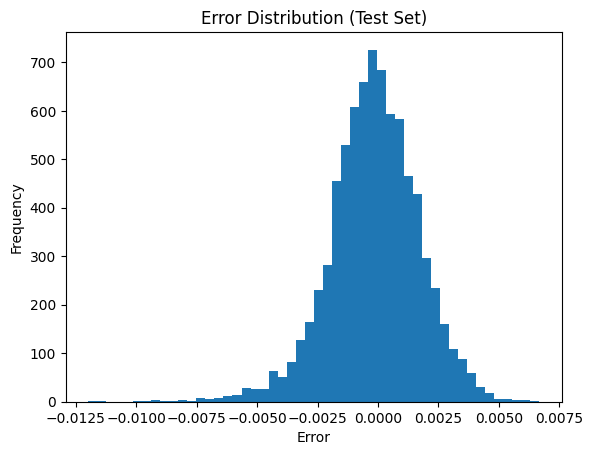

In [23]:
y_pred = xgb_model.predict(X_test_sc)
errors = y_pred - y_test

plt.hist(errors, bins=50)
plt.title("Error Distribution (Test Set)")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

##Demonstrasi dampak correction ke durasi final

In [24]:
print("\nDemonstrasi dampak correction pada durasi final:")
print(" " * 60)
print(f"{'Kondisi':<20} {'Correction':>12} {'Durasi Base':>13} "
      f"{'Durasi Final':>13}")
print(" " * 60)

MED_LOWER = {1: 200, 2: 250, 3: 300, 4: 450, 5: 600, 6: 1000}

test_cases = [
    ("Lembap, berangin", 85, 10, 28),
    ("Normal",           70,  4, 30),
    ("Kering, panas",    40,  2, 36),
]

uvi_example   = 8
skin_example  = 3
durasi_base   = MED_LOWER[skin_example] / (uvi_example * 1.5)

for label, rh, ws, t in test_cases:
    # Feature engineering untuk satu sampel
    hr, bulan = 12, 6
    hr_sin    = np.sin(2 * np.pi * hr / 24)
    hr_cos    = np.cos(2 * np.pi * hr / 24)
    bulan_sin = np.sin(2 * np.pi * bulan / 12)
    bulan_cos = np.cos(2 * np.pi * bulan / 12)
    rh_x_t    = rh * t
    rh_x_ws   = rh * ws

    sample = [[t, rh, ws, hr_sin, hr_cos,
               bulan_sin, bulan_cos, rh_x_t, rh_x_ws]]
    sample_sc   = scaler.transform(sample)
    correction  = float(best_model.predict(sample_sc)[0])
    durasi_final = round(min(durasi_base * correction, 120.0), 1)

    print(f"{label:<20} {correction:>12.4f} {durasi_base:>13.1f} "
          f"{durasi_final:>13.1f}")

print(f"(UV Index={uvi_example}, Skin Type={skin_example}, "
      f"Durasi base={durasi_base:.1f} menit)")
print(" " * 60)


Demonstrasi dampak correction pada durasi final:
                                                            
Kondisi                Correction   Durasi Base  Durasi Final
                                                            
Lembap, berangin           1.0701          25.0          26.8
Normal                     1.0005          25.0          25.0
Kering, panas              0.8956          25.0          22.4
(UV Index=8, Skin Type=3, Durasi base=25.0 menit)
                                                            


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


##Save model

In [25]:
joblib.dump({
    'model':      best_model,
    'model_name': best_name,
    'scaler':     scaler,
    'features':   FEATURES,
    'target':     TARGET,
    'test_mae':   test_mae,
    'test_r2':    test_r2,
    'note': (
        'Correction factor berbasis kondisi atmosfer non-UV. '
        'Input: T2M, RH2M, WS2M + fitur waktu + interaksi. '
        'UV Index tidak digunakan sebagai fitur. '
        'Target diturunkan dari formula atmosfer, bukan UV Index.'
    )
}, 'model_correction.joblib')

print(f"Model '{best_name}' disimpan ke model_correction.joblib")

Model 'XGBoost' disimpan ke model_correction.joblib


## Save Deployment Pipeline

In [26]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("scaler", scaler),
    ("model", best_model)
])

joblib.dump(pipeline, "correction_pipeline.pkl")
print("Deployment pipeline saved to correction_pipeline.pkl")

Deployment pipeline saved to correction_pipeline.pkl


##Inference function

In [27]:
MED_LOWER = {1: 200, 2: 250, 3: 300, 4: 450, 5: 600, 6: 1000}

In [28]:
SKIN_TYPE_INFO = {
    1: {
        "nama_kulit": "Sangat cerah, selalu terbakar, tidak pernah kecokelatan",
        "spf_min": 30,
        "tips": [
            "Oleskan sunscreen SPF 30+ minimal 15–30 menit sebelum keluar.",
            "Ulangi pemakaian sunscreen setiap 2 jam, "
            "atau segera setelah berenang dan berkeringat.",
            "Gunakan topi bertepi lebar dan kacamata anti-UV saat beraktivitas luar.",
            "Hindari paparan langsung antara pukul 10.00–16.00.",
        ]
    },
    2: {
        "nama_kulit": "Kulit cerah, mudah terbakar, sulit kecokelatan",
        "spf_min": 30,
        "tips": [
            "Gunakan sunscreen SPF 30+ setiap hari, termasuk saat mendung.",
            "Topi bertepi lebar dan kacamata anti-UV wajib saat ke luar ruangan.",
            "Ulangi pemakaian sunscreen setiap 2 jam.",
            "Pertimbangkan SPF 50+ untuk aktivitas luar ruangan yang lama.",
        ]
    },
    3: {
        "nama_kulit": "Kulit sedang, terbakar secukupnya, perlahan kecokelatan",
        "spf_min": 30,
        "tips": [
            "Gunakan sunscreen SPF 30+ setiap hari.",
            "Ulangi pemakaian setiap 2 jam saat beraktivitas di luar.",
            "Kenakan pakaian pelindung dan topi saat jam UV puncak.",
        ]
    },
    4: {
        "nama_kulit": "Kulit zaitun, jarang terbakar, mudah kecokelatan",
        "spf_min": 30,
        "tips": [
            "Gunakan sunscreen SPF 30+ setiap hari.",
            "Topi bertepi lebar dan kacamata membantu melindungi "
            "area wajah dan sekitar mata.",
            "Ulangi pemakaian sunscreen setelah berenang atau berkeringat.",
        ]
    },
    5: {
        "nama_kulit": "Kulit cokelat, jarang terbakar, mudah dan cepat kecokelatan",
        "spf_min": 15,
        "tips": [
            "Gunakan sunscreen SPF 15+ terutama pada jam UV puncak.",
            "Kenakan topi dan kacamata saat beraktivitas lama di luar.",
            "Kulit yang tahan sekalipun tetap membutuhkan perlindungan harian.",
        ]
    },
    6: {
        "nama_kulit": "Kulit gelap, sangat jarang terbakar, selalu kecokelatan pekat",
        "spf_min": 15,
        "tips": [
            "Gunakan sunscreen SPF 15–30 setiap hari untuk kesehatan kulit jangka panjang.",
            "Kenakan kacamata dan topi bertepi lebar saat paparan matahari lama.",
            "Kerusakan kulit akibat UV tetap bisa terjadi meski tanpa sunburn — "
            "perlindungan harian tetap penting.",
        ]
    }
}

In [29]:
UV_CATEGORIES = [
    (0,  2,  "Rendah",        "green",  "Aman"),
    (3,  5,  "Sedang",        "yellow", "Perhatian"),
    (6,  7,  "Tinggi",        "orange", "Hati-hati"),
    (8,  10, "Sangat Tinggi", "red",    "Berbahaya"),
    (11, 99, "Ekstrem",       "violet", "Berbahaya"),
]

In [30]:
def get_uv_category(uvi: float) -> tuple:
    for low, high, label, color, status in UV_CATEGORIES:
        if low <= uvi <= high:
            return label, color, status
    return "Ekstrem", "violet", "Berbahaya"

In [31]:
def get_spf_tips(uvi: float, skin_type: int) -> str:
    spf_min = SKIN_TYPE_INFO[skin_type]['spf_min']

    if uvi >= 8:
        spf_rec = max(spf_min, 50)
        reapply = "setiap 1–2 jam"
    elif uvi >= 6:
        spf_rec = max(spf_min, 30)
        reapply = "setiap 2 jam"
    elif uvi >= 3:
        spf_rec = max(spf_min, 30)
        reapply = "setiap 2–3 jam"
    else:
        spf_rec = spf_min
        reapply = "setiap 3–4 jam jika beraktivitas lama"

    return (
        f"Gunakan sunscreen minimal SPF {spf_rec}+ "
        f"dan ulangi pemakaian {reapply}."
    )

Pipeline inference SYNAR — output trimmed untuk UI.

  Input:
  * uvi       : UV Index dari NASA API
  * skin_type : Fitzpatrick 1–6 dari output CNN
  * t2m       : Suhu (°C)
  * rh2m      : Kelembapan (%)
  * ws2m      : Kecepatan angin (m/s)
  * hr        : Jam saat ini (0–23)
  * bulan     : Bulan saat ini (1–12)

  Output:
  * uv_index          : nilai UV Index
  * uv_label          : label kategori (Rendah/Sedang/dll)
  * uv_color          : warna indikator untuk UI
  * durasi_aman_menit : durasi final setelah koreksi
  * safety_status     : Aman / Perhatian / Hati-hati / Berbahaya
  * safety_note       : kalimat pendek untuk status bar
  * tips_spf          : tips SPF singkat (untuk bagian TIPS di UI)
  * tips_personal     : list tips personal per tipe kulit

In [32]:
def predict_correction(t2m, rh2m, ws2m, hr, bulan):
    hr_sin    = np.sin(2 * np.pi * hr / 24)
    hr_cos    = np.cos(2 * np.pi * hr / 24)
    bulan_sin = np.sin(2 * np.pi * bulan / 12)
    bulan_cos = np.cos(2 * np.pi * bulan / 12)
    rh_x_t    = rh2m * t2m
    rh_x_ws   = rh2m * ws2m

    sample = [[t2m, rh2m, ws2m, hr_sin, hr_cos,
               bulan_sin, bulan_cos, rh_x_t, rh_x_ws]]
    sample_sc  = scaler.transform(sample)
    correction = float(best_model.predict(sample_sc)[0])
    return round(np.clip(correction, 0.80, 1.20), 4)

In [33]:
def predict_synar(uvi: float, skin_type: int,
                  t2m: float, rh2m: float,
                  ws2m: float, hr: int,
                  bulan: int) -> dict:


    med = MED_LOWER[skin_type]
    durasi_base = round(min(
        med / (uvi * 1.5), 120.0
    ), 1) if uvi > 0 else 120.0


    correction   = predict_correction(t2m, rh2m, ws2m, hr, bulan)
    durasi_final = round(min(durasi_base * correction, 120.0), 1)

    # Step 3: UV category
    uv_label, uv_color, _ = get_uv_category(uvi)

    # Step 4: Safety status berbasis durasi akhir
    if durasi_final >= 30:
        safety_status = "Aman"
        safety_note   = "Aman untuk beraktivitas di luar ruangan."
    elif durasi_final >= 15:
        safety_status = "Perhatian"
        safety_note   = "Gunakan perlindungan ekstra saat keluar."
    elif durasi_final >= 10:
        safety_status = "Hati-hati"
        safety_note   = "Batasi waktu di bawah matahari langsung."
    else:
        safety_status = "Berbahaya"
        safety_note   = "Hindari paparan langsung jika memungkinkan."

    if uvi >= 11 and safety_status == "Aman":
        safety_status = "Perhatian"
        safety_note   = (
            "UV Ekstrem. Tetap gunakan perlindungan "
            "meski kulit lebih tahan."
        )

    if durasi_final >= 120:
        durasi_display = "> 120 menit"
    else:
        durasi_display = f"{durasi_final} menit"

    # Step 5: Tips
    tips_spf      = get_spf_tips(uvi, skin_type)

    base_tips = list(SKIN_TYPE_INFO[skin_type]['tips'])
    if uvi >= 8:
        base_tips.insert(0,
            "UV sangat tinggi hari ini — tingkatkan frekuensi "
            "pemakaian sunscreen dan minimalkan waktu di luar."
        )
    tips_personal = base_tips

    return {
        "uv_index":          uvi,
        "uv_label":          uv_label,
        "uv_color":          uv_color,
        "safety_status":     safety_status,
        "durasi_aman_menit": durasi_final,
        "durasi_display":    durasi_display,
        "safety_note":       safety_note,
        "tips_spf":          tips_spf,
        "tips_personal":     tips_personal,
    }

##Inference function

In [34]:
test_cases_inference = [
    ("UV rendah, sore hari",     2, 3, 28, 75, 2.0, 15, 5),
    ("UV sedang, pagi hari",     4, 2, 27, 72, 1.5,  9, 8),
    ("UV tinggi, siang hari",    7, 4, 31, 80, 2.5, 12, 6),
    ("UV ekstrem, kulit tipe 6", 12, 6, 33, 70, 3.0, 13, 7),
    ("UV = 0 (malam/mendung)",   0, 3, 26, 85, 1.0, 20, 4),
]

for label, uvi, skin, t, rh, ws, hr, bln in test_cases_inference:
    result = predict_synar(uvi, skin, t, rh, ws, hr, bln)
    print(f"\n{'─'*55}")
    print(f"Skenario : {label}")
    print(f"INDEKS UV: {result['uv_index']} ({result['uv_label']})")
    print(f"STATUS   : {result['safety_status']}")
    print(f"BATAS AMAN: {result['durasi_display']}")  # ← pakai display
    print(f"TIPS     : {result['tips_spf']}")
    print(f"NOTE     : {result['safety_note']}")
    print(f"TIPS PERSONAL:")
    for tip in result['tips_personal']:
        print(f"  • {tip}")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



───────────────────────────────────────────────────────
Skenario : UV rendah, sore hari
INDEKS UV: 2 (Rendah)
STATUS   : Aman
BATAS AMAN: 100.5 menit
TIPS     : Gunakan sunscreen minimal SPF 30+ dan ulangi pemakaian setiap 3–4 jam jika beraktivitas lama.
NOTE     : Aman untuk beraktivitas di luar ruangan.
TIPS PERSONAL:
  • Gunakan sunscreen SPF 30+ setiap hari.
  • Ulangi pemakaian setiap 2 jam saat beraktivitas di luar.
  • Kenakan pakaian pelindung dan topi saat jam UV puncak.

───────────────────────────────────────────────────────
Skenario : UV sedang, pagi hari
INDEKS UV: 4 (Sedang)
STATUS   : Aman
BATAS AMAN: 41.7 menit
TIPS     : Gunakan sunscreen minimal SPF 30+ dan ulangi pemakaian setiap 2–3 jam.
NOTE     : Aman untuk beraktivitas di luar ruangan.
TIPS PERSONAL:
  • Gunakan sunscreen SPF 30+ setiap hari, termasuk saat mendung.
  • Topi bertepi lebar dan kacamata anti-UV wajib saat ke luar ruangan.
  • Ulangi pemakaian sunscreen setiap 2 jam.
  • Pertimbangkan SPF 50+ untuk 

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## Requirements.txt

In [35]:
!pip freeze > requirements.txt